<div style="font-family: Georgia;; font-size:37px;"> <b>INTERNET USAGE ANALYSIS</b></div>


<p style="font-family: Courier; font-size:30px;"> <b>INTRODUCTION </p>

 <div style="font-family: 'Times New Roman'; font-size:20px;background-color:#B0E0E6; padding:5px;"> 
    The Internet is a global network that connects billions of people and devices, enabling communication, information sharing, and access to digital services. Internet usage refers to how individuals and groups interact with this network in daily life, through activities such as browsing, social media, streaming, online shopping, education, and work. Internet usage influences education, business, healthcare, and social interaction, but excessive screen time raises concerns about health and well-being. Which implies, internet usage is a driver of global progress and at same time it also requires to maintain a healthy and overall digital participation, requiring efforts to expand access while promoting healthy online habits.<br>
<br>
<b>What is internet usage analysis? </b> Internet usage analysis is the study of how individuals and groups interact with digital technologies, focusing on access, screen time, demographics, and behavioral patterns.
<br><br>
<b>Aim of this project : </b>  The aim of this project is to analyse internet usage in different people based on the screentime they spend on social meadia, entertainment and work/study platforms and age.<br><br>
     
<b>How is Internet usage analysis useful? </b>  In today’s hyper-connected world, the internet has become a fundamental utility for shaping communication, commerce, education, entertainment, and governance. Understanding usage trends is crucial for policymakers, businesses, educators, and researchers, as it reveals both opportunities and challenges in the digital age. Identifying customer behavior patterns is informative for <b>business and marketing </b>by personalizing product recommendations and improving customer engagement. On <b>education sector</b>, measuring screen time to balance digital learning with offline activities. On <b>healthcare</b> it is applicable to study the impact of excessive screen time on mental and physical health. From <b>government</b> side it can be used for guiding infrastructure investments in broadband and mobile networks. Also, it is used for shaping screen time limit for children. It is beneficial for <b>technology development</b> by improving user experience in apps and websites by analyzing usage trends. Internet usage analysis is worth for <b> social research</b>, for example, studying the role of internet usage in shaping culture, communication, and relationships.<br>
<br>
<b>Dataset</b> for this project is taken from Kaggle. [Dataset Link](https://www.kaggle.com/code/nuhmanpk/daily-internet-usage-analysis)

</div> 

<p style="font-family: Courier; font-size:30px;"> <b>DATA LOADING AND INITIAL OVERVIEW  </p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('daily_internet_usage_by_age_group.csv')

In [3]:
df.head()

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi


In [4]:
df.shape

(2800, 10)

<div class="alert alert-info"> 
The dataset contains 2800 rows and 10 columns.<br>
    Details of columns:<br>
    <b>user_id : </b> Id of each individuals.<br>
    <b>date : </b> Observed date.<br>
    <b>age : </b> Age of individuals.<br>
    <b>age_group : </b> Categorized age into 6 groups.<br>
    <b>social_meadia_hours : </b> Hours spent on social meadia per day via internet.<br>
    <b>work_or_study_hours : </b> Hours spent on work or study per day via internet.<br>
    <b>entertainment_hours : </b> Hours spent on entertainment per day via internet.<br>
    <b>total_screen_time: </b> Total hours spent on the internet per day using various platforms.<br>
    <b>primary_device : </b> Devices used.<br>
    <b>internet_type : </b> Internet type used.
</div>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2800 non-null   int64  
 1   date                 2800 non-null   object 
 2   age                  2800 non-null   int64  
 3   age_group            2800 non-null   object 
 4   social_media_hours   2800 non-null   float64
 5   work_or_study_hours  2800 non-null   float64
 6   entertainment_hours  2800 non-null   float64
 7   total_screen_time    2800 non-null   float64
 8   primary_device       2800 non-null   object 
 9   internet_type        2800 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 218.9+ KB


<div style="font-family: Garamond; font-size:15px;"><b>Age groups - </b> have 6 groups
</div>

In [6]:
print(sorted(df['age_group'].unique()))

['13-18', '19-25', '26-35', '36-45', '46-60', '60+']


<div style="font-family: Garamond; font-size:15px;"><b>Devices used - </b> 3 devices</div>

In [7]:
print(df['primary_device'].unique())

['Mobile' 'Tablet' 'Laptop']


<div style="font-family: Garamond; font-size:15px;"><b>Internet type used - </b> 2 types</div>

In [8]:
print(df['internet_type'].unique())

['WiFi' 'Mobile Data']


In [9]:
df[['age','social_media_hours','work_or_study_hours','entertainment_hours','total_screen_time']].describe()

,age,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,38.397500,2.117143,4.016107,2.021929,8.155179
std,18.436556,1.113908,1.722615,0.876120,2.211885
min,13.000000,0.200000,1.000000,0.500000,2.000000
25%,22.000000,1.100000,2.500000,1.300000,6.600000
50%,35.000000,2.100000,4.000000,2.000000,8.100000
75%,53.000000,3.100000,5.500000,2.800000,9.700000
max,75.000000,4.000000,7.000000,3.500000,14.000000


<div class="alert alert-info"> 
    <b>STATISTICAL ANALYSIS </b> <br>
    <br>
    <b><u>Age :</u></B><br>
    &#10143;Ranges from 13 to 75.<br>
    &#10143;Most of the people are around 35 to 38.<br>
    <b><u>Social media hours :</u></B><br>
    &#10143;Minimum and maximum time observed: 0.2 and 4 hours<br>
    &#10143;The average time spent is 2.1 hours/day.<br>
    <b><u>Work or study hours :</u></B><br>
    &#10143;Minimum and maximum time observed: 1 and 7 hours<br>
    &#10143;The average time spent is 4 hours/day.<br>
    <b><u>Entertainment hours :</u></B><br>
    &#10143;Minimum and maximum time observed: 0.5 and 3.5 hours<br>
    &#10143;The average time spent is 2 hours/day.<br>
    <b><u>Total screen time :</u></B><br>
    &#10143;Minimum and maximum time observed: 2 and 14 hours<br>
    &#10143;The average time spent is 8.1 hours/day.<br>
    &#10143;25% of people exceeds 9.7 hours.
</div>

<p style="font-family: Courier; font-size:30px;"> <b>DATA PRE-PROCESSING  </p>

<div style="font-family: Garamond; font-size:15px;"><b>Checking missing values</div>

In [10]:
df.isnull().sum()

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64

No missing values.

<div style="font-family: Garamond; font-size:15px;"><b>Checking duplicates</div>

In [11]:
print(df.duplicated().sum())

0


No duplicates

<div style="font-family: Garamond; font-size:15px;"><b>Storing dataset into a variable "data"</div>

In [12]:
data=df

<div style="font-family: Garamond; font-size:15px;"><b>Changed datatype of 'date' into 'datetime'</div>

In [13]:
data['date']=pd.to_datetime(data['date'])

In [14]:
# Check if data type changed
str(data['date'].dtype)

'datetime64[ns]'

<div style="font-family: Garamond; font-size:15px;"><b>Sorted values according to date in acsending order</div>

In [15]:
data=data.sort_values('date')

<div style="font-family: Garamond; font-size:15px;"><b>Replaced '60+', one of age group, into '60 above'</div>

In [16]:
data['age_group']=data['age_group'].replace('60+','60 above')

<div style="font-family: Garamond; font-size:15px;"><b><u>Derived Columns</u> - </b> created 5 columns</div>

<div style="font-family: Garamond; font-size:15px;">i. <b>Day name</b></div>

In [17]:
data['day']=data['date'].dt.day_name()

<div style="font-family: Garamond; font-size:15px;">ii. <b>Month Name</div>

In [18]:
data['month']=data['date'].dt.month_name()

<div style="font-family: Garamond; font-size:15px;">iii. <b> Status-</b> Designation of individuals<pre>
          student(age<=25),<br>
          working(26<=age>=65),<br>
          retired(age>65)
           </pre>
           </div>

In [19]:
data['status']=np.where(data['age']<=25,'student',np.where(data['age'] > 65, 'retired','working'))

<div style="font-family: Garamond; font-size:15px;">iv. <b>Leisure time -</b> social media + entertainment hours</div>

In [20]:
data['leisure_time']=df['total_screen_time']-df['work_or_study_hours']

<div style="font-family: Garamond; font-size:15px;">v. <b>Healthy time -</b> it means mental health. The advised time is less than 3 hours.</div>

In [21]:
data['healthy']=data['leisure_time']<3

<div style="font-family: Garamond; font-size:15px;"><b>Final Data after making changes</div>

In [22]:
data.head()

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type,day,month,status,leisure_time,healthy
419,420,2024-01-01,23,19-25,1.6,2.5,1.8,5.9,Mobile,WiFi,Monday,January,student,3.4,False
2055,2056,2024-01-01,38,36-45,4.0,3.7,2.7,10.4,Mobile,WiFi,Monday,January,working,6.7,False
434,435,2024-01-01,71,60 above,3.6,2.8,2.3,8.7,Tablet,WiFi,Monday,January,retired,5.9,False
399,400,2024-01-01,35,26-35,3.1,2.4,1.4,6.9,Laptop,Mobile Data,Monday,January,working,4.5,False
2496,2497,2024-01-01,61,60 above,1.9,1.5,3.2,6.6,Laptop,WiFi,Monday,January,working,5.1,False


<p style="font-family: Courier; font-size:30px;"> <b>EDA  AND VISUALIZATION </b> </p> 

<p style="font-family: 'Times New Roman'; font-size:25px;"> <b>EXPLORATORY DATA ANALYSIS </p>

<div style="font-family: Garamond; font-size:15px;"><b>Number of people who spend more screen time on work or study</div>

In [23]:
len(data[data['leisure_time']<data['work_or_study_hours']])

1322

<div class="alert alert-info"> 
    47% of people spent more screen time on work/study.
</div>

<div style="font-family: Garamond; font-size:15px;"><b>Number of people who spend more screen time on leisure activities</div>

In [24]:
len(data[data['leisure_time']>=data['work_or_study_hours']])

1478

<div class="alert alert-info"> 
53% of people spent their screen time more on leisure activities.
    </div>

<div style="font-family: Garamond; font-size:15px;"><b>Average Screen Time distribution based on status of people</div>

In [25]:
data.groupby('status')[['leisure_time','work_or_study_hours','total_screen_time']].mean().round({
              'leisure_time': 2,'work_or_study_hours': 2,'total_screen_time': 2}).rename(columns=
                    {'work_or_study_hours':'work hours','total_screen_time':'total hours','leisure_time':'free hours'})

,free hours,work hours,total hours
status,,,
retired,3.97,3.98,7.95
student,4.12,3.98,8.11
working,4.18,4.04,8.23


<div class="alert alert-info"> 
&#9642; <b>Online leisure activities:</b> Retirees average the lowest , while students and employees are slightly higher.<br>
&#9642; Retirees may prefer offline activities more.<br>
&#9642; <b>Work/Study:</b>  Around 4 hours for all groups.<br>
&#9642; Employees have highest total screen time due to high engagement in all components.<br>
&#9642; Retirees have lowest screen time.
</div>

<div style="font-family: Garamond; font-size:15px;"><b>Minimum hours observed on Retirees,Students and Employees.</div>

In [26]:
data.groupby('status')[['social_media_hours','work_or_study_hours','entertainment_hours','total_screen_time']].min()

,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time
status,,,,
retired,0.2,1.0,0.5,2.9
student,0.2,1.0,0.5,2.0
working,0.2,1.0,0.5,2.3


<div class="alert alert-info"> 
&#9642; This suggests that at least one individual in each group has very similar minimum screen usage patterns.<br>
&#9642; The minimum values for <b>social_media_hours (0.2), work_or_study_hours (1.0), and entertainment_hours (0.5)</b> are identical across retirees, students, and employees.<br>
&#9642; Even though the component minimums are the same, the total screen time minimum differs.<br>
&#9642; <b>Students </b>show the lowest <b>minimum total screen time (2.0)</b>.<br>
&#9642; <b>Retirees</b> have highest <b>minimum total screen time (2.9)</b>.

</div>

<div style="font-family: Garamond; font-size:15px;"><b>Maximum hours observed on Retirees,Students and Employees.</div>

In [27]:
data.groupby('status')[['social_media_hours','work_or_study_hours','entertainment_hours','total_screen_time']].max()

,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time
status,,,,
retired,4.0,6.9,3.5,12.8
student,4.0,7.0,3.5,13.9
working,4.0,7.0,3.5,14.0


<div class="alert alert-info"> 
        &#9642; Maximum time spend on every components in total screen time is same for every category.<br>
        &#9642; That is, age doesn't have any effect on preference. It is completely personal.<br>
        &#9642; Even though the component maximums are the same, the maximum total screen time differs.<br>
        &#9642; <b>Retirees have lowest maximum total screen time (12.8 hours)</b>, no retirees goes beyond the screen time 12.8 hours/day.<br>
        &#9642; <b>Employees and Students have highest maximum time (~14 hours).</b>
    
</div>

<div style="font-family: Garamond; font-size:15px;"><b>Number of people who spend screen time more than 11 hours</div>

In [28]:
data[data['total_screen_time'] > 11].groupby('status').size().reset_index()

,status,0
0,retired,31
1,student,97
2,working,168


<div class="alert alert-info"> 
<b>Details of people who spend more than 11 hours daily:</b><br>
&#9679; 9.6% of retirees<br>
&#9679; 10.% of students<br>
&#9679; 10.8% of employees<br>
&#9679; 10.5% of total<br>
&#9679; Almost 10% to 11% of individuals from each group spend more than 11 hours per day in screen.
</div>

**PIVOT TABLE-** count of people having healthy screen time among different categories

In [29]:
pivot_time=data.pivot_table(index=['status','healthy'],values='user_id',aggfunc='count').rename(columns={'user_id':'count'})
pivot_time

count
status  healthy       
retired False      243
        True        79
student False      745
        True       180
working False     1215
        True       338

<div class="alert alert-info"> 

&#10140; 75% of **Retirees** not having healthy screen time.<br>
&#10140; 80% of **Students** not having healthy screen time.<br>
&#10140; 78% of **Employees** not having healthy screen time.<br>
&#10140; A high proportion of people are not maintaining healthy screen time.<br>
&#10140; Findings suggest unhealthy leisure screen time patterns among most individuals, highlighting the need for measures to improve digital well-being.
    
</div>

**PIVOT TABLE -** daily average screen time

In [30]:
pivot_date=data.pivot_table(index='date',
                            values=['social_media_hours','work_or_study_hours','entertainment_hours','total_screen_time'],
                            aggfunc={'social_media_hours':'mean','work_or_study_hours':'mean',
                                     'entertainment_hours':'mean','total_screen_time':'mean'})
pivot_date

,entertainment_hours,social_media_hours,total_screen_time,work_or_study_hours
date,,,,
2024-01-01,2.550000,2.525000,8.712500,3.637500
2024-01-02,2.240000,2.240000,9.380000,4.900000
2024-01-03,2.310000,2.440000,8.840000,4.090000
2024-01-04,1.966667,2.688889,8.766667,4.111111
2024-01-05,2.016667,2.591667,8.666667,4.058333
...,...,...,...,...
2024-12-27,2.581818,2.245455,8.736364,3.909091
2024-12-28,1.760000,2.500000,8.750000,4.490000
2024-12-29,2.025000,1.800000,8.600000,4.775000


<div class="alert alert-info"> 
&#9679; The table contains 366 rows and 4 columns - soacial media hours, entertainment hours, work/study hours and total screen time.<br>
&#9679; Each day is taken into consideration.<br>
&#9679; Each row represents the mean hours spent on social media, work/study, entertainment, and total screen time on that day.<br>
&#9679; It helps to analyze how daily behavior shifts across the population.<br>
&#9679; This table can be used <b>for trend analysis</b> - how screen time changes daily, <b>to compare activities</b> - how social meadia,entertainment and work/study contribute to total screen time, and <b>to identify peaks</b> - spot days with unusually high usage.
</div>

<p style="font-family: 'Times New Roman'; font-size:20px;"> <b>VISUALIZATION </p>

**COUNT PLOT-** counts of people from different age groups

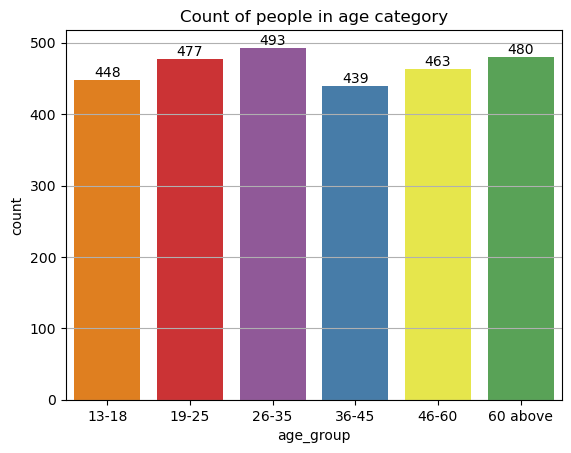

In [31]:
age_order = sorted(data['age_group'].unique())
age = sns.countplot(data=data,x='age_group',order=age_order,hue='age_group',palette='Set1')
for c in age.containers:
    age.bar_label(c,label_type='edge')
plt.grid(axis='y')
plt.title('Count of people in age category')
plt.show()

<div class="alert alert-info"> 
    &#9673; From the graph the age group ranges from <b>26 to 35 </b>are observed to be high, which is 18% of total.<br>
    &#9673; The next highest category is <b>60 Above</b>, which is 17.1% of overall data.<br>
    &#9673; The least numbered category is <b>'36 - 45'</b>, that is 15.6% of data.<br>
    &#9673; The second least category is <b>'13 - 18'</b>, represent 16%.<br>
    &#9673; The category <b>'13 - 18'</b> constitute 17% and <b>'36 - 45'</b> is 16.5%.    
</div>

**SCATTERPLOT-** To find relationship between age and screen time

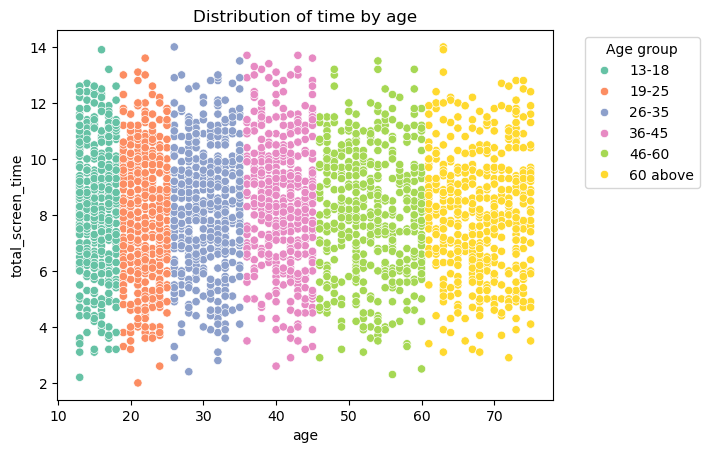

In [32]:
age_order = sorted(data['age_group'].unique())
sns.scatterplot(data,x='age',y='total_screen_time',hue='age_group',hue_order=age_order,palette='Set2')
plt.legend(title='Age group',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Distribution of time by age')
plt.show()

<div class="alert alert-info"> 
   &#9673; Every age group shows individuals with both low and high screen time, meaning habits vary greatly within groups.<br>
   &#9673; Teens (13–18) clustered between 6 to 12 screen time.<br>
   &#9673; Young adults (19–25) spread across 6 to 11 hours and Young adults(26-35) spread across 7 to 10 hours.<br>
   &#9673; Middle-aged (36–45) concentrated around 6 to 10 hours and while Middle-aged (46-60) screen time is scattered but lies mostly between 6 to 11 hours<br>
   &#9673; Older adults (60+): More scattered, with some lower totals (~4–6 hours) but still a significant number above 8 hours.<br>
   &#9673; Variation within groups is larger than variation between groups. For example, some 19–25-year-olds spend only ~3 hours, while others exceed 12.


</div>

**PIE CHART-** Time distribution

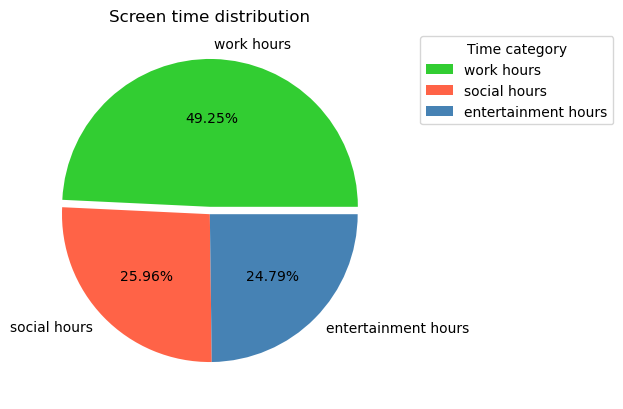

In [33]:
work=data['work_or_study_hours'].sum()
social=data['social_media_hours'].sum()
entertain=data['entertainment_hours'].sum()

plt.pie([work,social,entertain],labels=['work hours','social hours','entertainment hours'],autopct='%1.2f%%',
        explode=(0.05,0,0),colors=['limegreen','tomato','steelblue'])
plt.title('Screen time distribution')
plt.legend(title="Time category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<div class="alert alert-info"> 
   &#9673;Nearly half of the online hours is dedicated to work or study-related activities.<br>
    &#9673;About one-quarter (25.96%) of screen time is spent on social media.<br>
    &#9673;Entertainment hours are slightly lesser than social meadia hours .<br>
    &#9673; Work dominates, but leisure (social + entertainment) together makes up just over half (≈51%). This means non-work activities slightly outweigh work-related screen time.<br>
    &#9673; Since there is only a slight difference between work/study hours and leisure activities, the chart hinted a balance between professional and personal digital use. 
 
</div>

**HISTOGRAM-** To show distribution of screen time usage in individuals

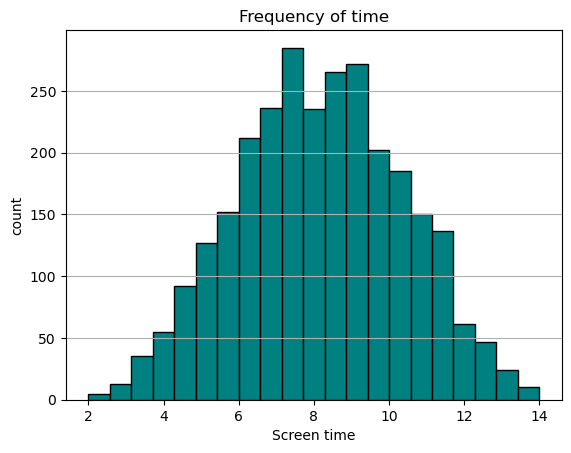

In [34]:
plt.hist(data['total_screen_time'],edgecolor='black',bins=21,color='teal')
plt.grid(axis='y')
plt.title('Frequency of time')
plt.xlabel('Screen time')
plt.ylabel('count')
plt.show()

<div class="alert alert-info"> 
        &#9673;The histogram resembles a bell curve, meaning most users cluster around the average, while fewer people spend very low or very high amounts of time online.<br>
 &#9673; Most of the people spend 7-9 hours daily in online activities, includes either social/entertainment media or work/study platforms. Since it has become the average time spend online.<br>
&#9673; So it is the most common daily screen time among individuals.<br>
&#9673; A few people have screen time greater than 12 hours per day, which needs an attention.<br>
    &#9673;Also, a few individuals (less than 0.01%) have less screen time which is less than 4 hours daily.<br>

</div>

**PIE CHART-** analysis of screen time on weekdays

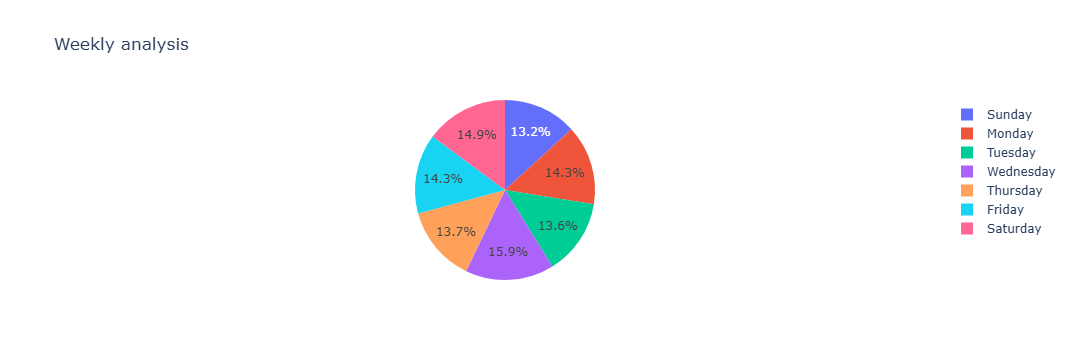

In [54]:
days=data.groupby('day')[['total_screen_time','work_or_study_hours']].sum().reset_index()
day_order=['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
px.pie(days,names='day',values='total_screen_time',title='Weekly analysis',hover_data=['work_or_study_hours'],category_orders={'day':day_order})

<div class="alert alert-info"> 
&#9673; Wednesday have high total screen time hours and high work/study hours<br>
    &#9673; Wednesday's higher share in work/study, tells that, a less usage in leisure activities.<br>
&#9673; Sunday have less total screen time hours and less work/study hours.<br>
    &#9673; Sunday's less hour in work/study shows a increase in spending time on online leisure activities.<br>
    &#9673; Monday, Tuesday, Thursday, and Friday are fairly balanced.<br>
    &#9673; It is observed that there is a sudden decrease in online work/study hours from Saturday to Sunday.<br>
</div>

**LINE PLOT-** To analyse daily screen time hours

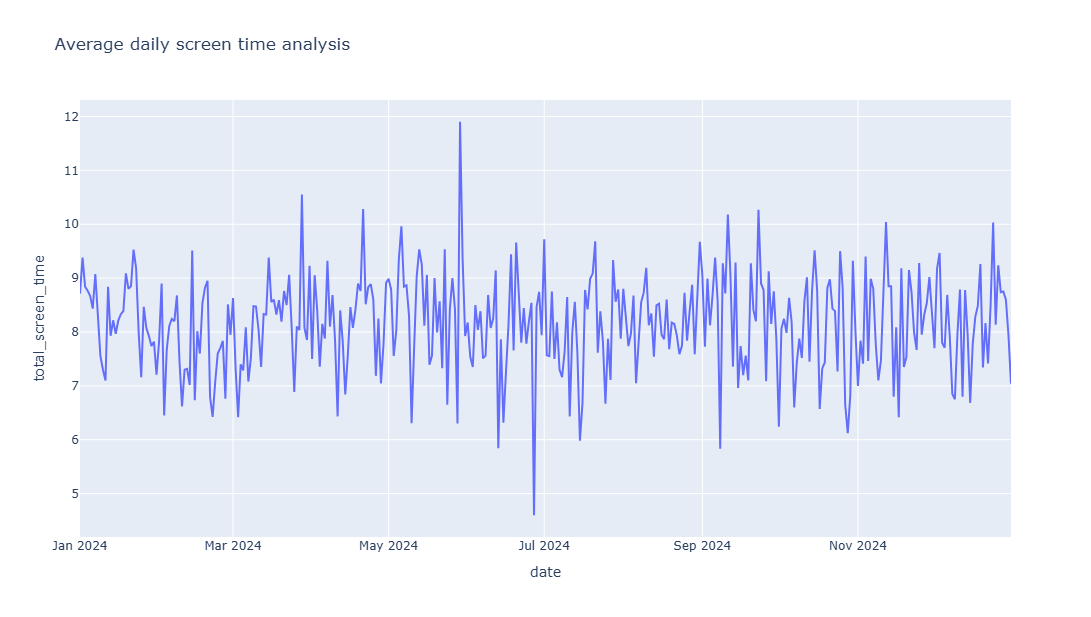

In [36]:
px.line(pivot_date,x=pivot_date.index,y='total_screen_time',width=1100,height=600,title='Average daily screen time analysis')

<div class="alert alert-info"> 
&#9673; From this line chart we can identify the peak and low screen time used day and also can be used to identify the screen time trend in a year.
    &#9673; The average screen time is consistent among 7 to 9 hours.<br>
   &#9673; The peak average screen time is observerd on may 29 (11.9 hours).<br>
   &#9673; A low average screen time is observed on june 27 (4.6 hours). <br>
    &#9673; The data mostly varies between 6 to 10 hours with very few observations marks outside the upper and lower limit.<br>
    &#9673; Noticeable spikes occur at certain months in mid year (March, April, May) and year end (September,November,December).<br>
    &#9673; Lower screen time appears in June,July and September. 
</div>

**LINE CHART-** daily distibution of time in different medias

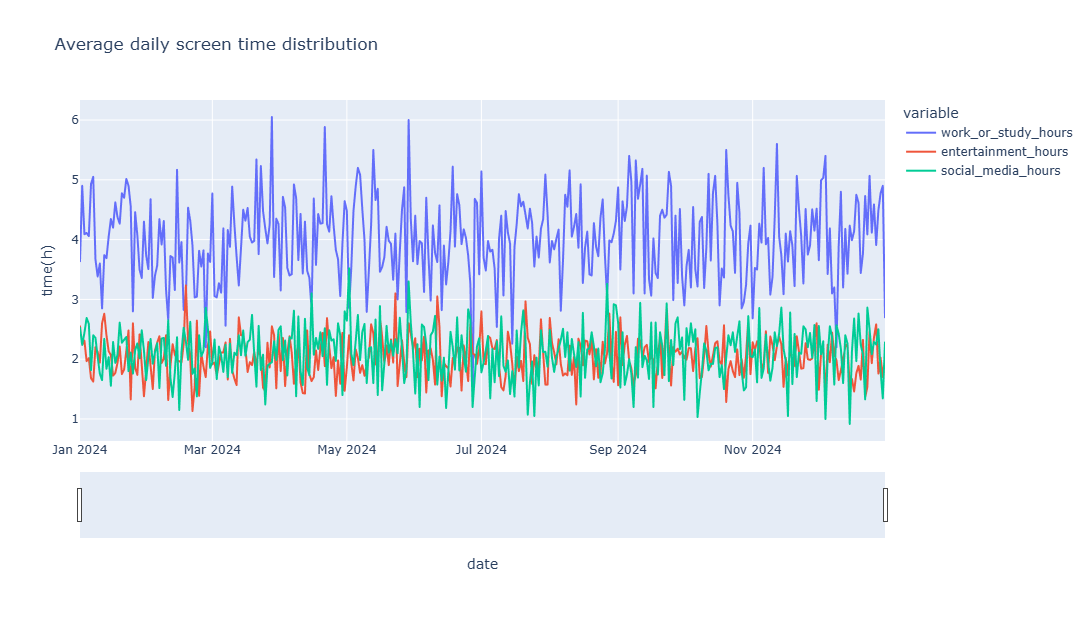

In [37]:
colms_plot=['work_or_study_hours','entertainment_hours','social_media_hours']
fig2=px.line(pivot_date,x=pivot_date.index,y=colms_plot,width=1100,height=600,title='Average daily screen time distribution')
fig2.update_xaxes(rangeslider_visible=True)
fig2.update_yaxes(title_text='time(h)')

<div class="alert alert-info">
&#10148; The graph shows an average daily screen time for work/study, social media and entertainment hours.<br>
&#10148;<b>Work/Study hours</b><br>
          &#9679; The lowest value observed is 1.3 on June 27<br>
          &#9679; The peak value 6.05 is marked on March 28, <br>
          &#9679; Screen time lies mostly between 3 to 5.5 hours with some low and peak values.   <br>       
&#10148;<b>Entertainment hours</b><br>
    &#9679; The lowest time is 1.1 which is noticed on February 21<br>
    &#9679; The high screen hour 3.2 appears to be on February 18<br>
    
&#10148;<b>Social media hours</b><br> 
    &#9679; The lowest time 0.91 spotted on December 15<br>
    &#9679; The greatest value 3.5 is noted on May2<br>

&#10148; Both social and entertainment hours spread between 1 to 3 expect few observations.
</div>

**COUNT PLOT-** counts of people based on their current status

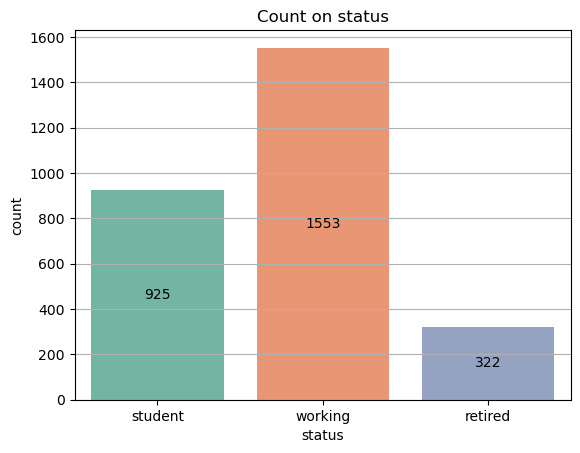

In [38]:
count_s=sns.countplot(data,x='status',hue='status',palette='Set2')
for c in count_s.containers:
    count_s.bar_label(c,label_type='center')
plt.title('Count on status')
plt.grid(axis='y')
plt.show()

<div class="alert alert-info"> 
    &#9673; The number of employees are very high compared to student and retired catogories.<br>
    &#9673; Retirees represent only a few in this data.<br>
    &#9673; 55% of data is employees<br>
   &#9673; 33% of data is students<br>
  &#9673; Only 12 % represent retirees
</div>

**BOX PLOT-** total screen time categorized by different status

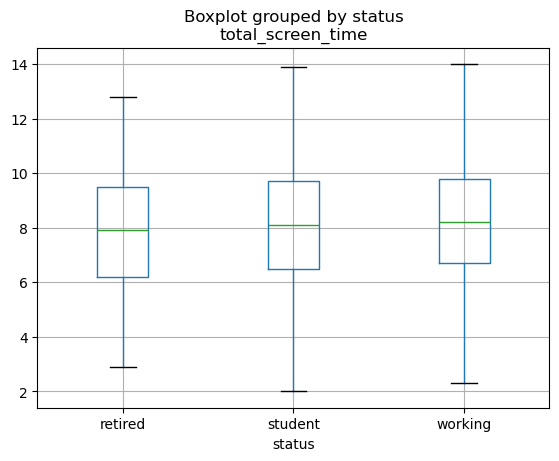

In [39]:
data.boxplot(column='total_screen_time',by='status')
plt.show()

<div class="alert alert-info">
   &#9673; Workers having high meadian screen time,followed by students<br>
    &#9673; Less meadian screen time is observed in retired people<br>
    &#9673; Workers and students show higher medians and wider ranges than retirees.<br>
    &#9673; All groups show individuals with very high screen time (close to 14 hours), which derive an extreme cases of digital dependence.<br>
    &#9673; Regardless of status, many individuals having an unhealthy screen time, with workers most at risk due to peak screen time usage.<br>
</div>

**STACKED BAR GRAPH-** to analyse healthy media time among different groups

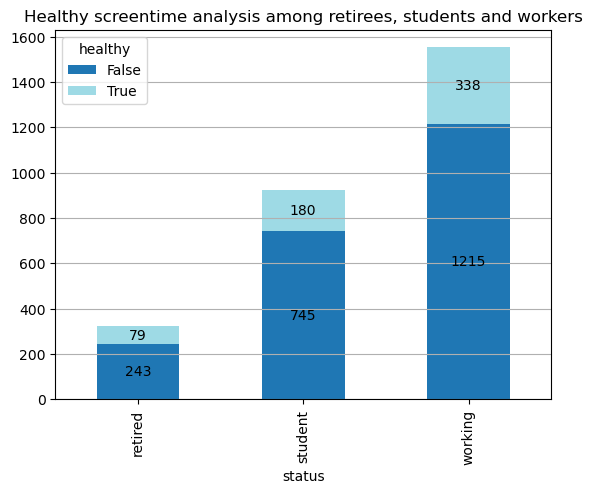

In [40]:
stack=data.groupby(['status','healthy']).size().unstack()
bar=stack.plot(kind='bar',stacked=True,colormap='tab20')

for c in bar.containers:
    bar.bar_label(c,label_type='center')
plt.grid(axis='y')
plt.title('Healthy screentime analysis among retirees, students and workers')
plt.show()

<div class="alert alert-info">
 &#9673; Most individuals, regardless of age or occupation, are not maintaining healthy screen time habits.<br>
&#9673; Across all groups, unhealthy screen time dominates, this explicit the fact that the engagement on social media or entertainment is higher than the specified limit.<br>
&#9673; Students have the highest proportion (80%) of unhealthy usage, slightly above retirees and workers.<br>
    &#9673; 78% of employees have unhealthy leisure activity time.<br>
&#9673; 75% of retirees have unhealthy leisure time.<br>
&#9673; This highlights the importance of digital well-being strategies tailored to each group.   <br>

**COUNT PLOT-** count of devices used among individuals grouped by their status

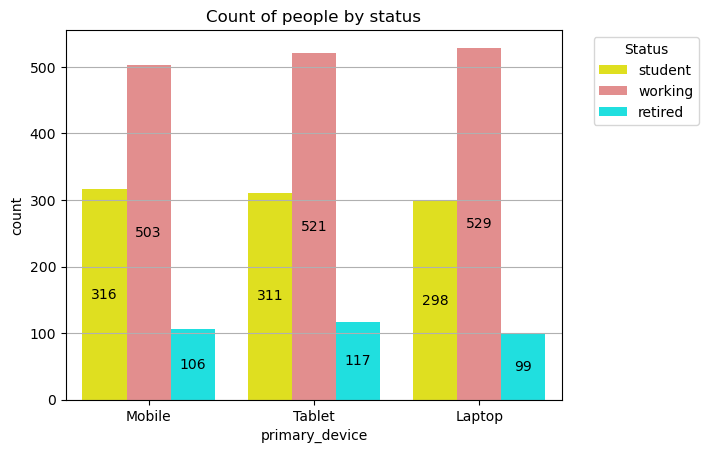

In [41]:
count_d=sns.countplot(data,x='primary_device',hue='status',palette=['yellow','lightcoral','cyan'])
for c in count_d.containers:
    count_d.bar_label(c,label_type='center')
plt.grid(axis='y')
plt.legend(title='Status',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Use of devices by status')
plt.show()

<div class="alert alert-info"> 
    According to this graph,<br>
   &#9673; Students are mostly engaged in mobiles and are least engaged in Laptop,34% of students are engaged in mobile phones while 32% in laptop.<br>
   &#9673; Employees are mostly engaged in laptops and are least in mobile, 34% in laptop and 32% in mobile.<br>
   &#9673; Retirees are mostly engaged in tablets, possibly due to ease of use and are least with laptops, 36% in tablets and 30% in laptop.<br>
  &#9673; Students show the most balanced use across devices, while workers lean slightly toward laptops.<br>
   &#9673; This show a high demand in all devices.<br>
</div>

**PIE CHART-** To find the proportion of devices used among people

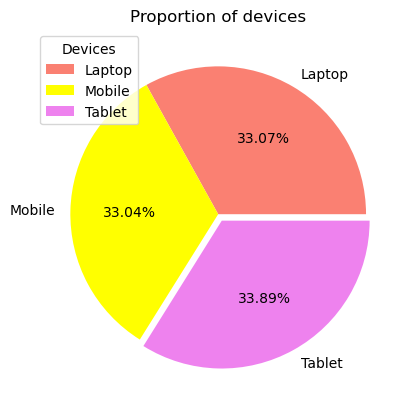

In [42]:
device_count=data.groupby('primary_device')['primary_device'].value_counts().reset_index()
device_count
plt.pie(data=device_count,x='count',labels='primary_device',autopct='%1.2f%%',explode=(0,0,0.05),colors=['salmon','yellow','violet'])
plt.title('Proportion of devices')
plt.legend(title='Devices')
plt.show()

<div class="alert alert-info"> 
&#9673;Laptop (33.07%), Mobile (33.04%), and Tablet (33.89%) usage are almost evenly split. <br>
   &#9673; When comparing three devices tablet shows a slight increase in demand, this could indicate a preference for portability with larger screens compared to mobiles.<br>
     &#9673; Users are spread across all three.<br>
     &#9673; With a slight difference laptop is in next position after tablet, this may be due to the large number of employees in this dataset.<br>
    &#9673; Even though employees number is high, mobile users are not far behind laptop. From this observation it can be assumed mobile users are higher.
</div>

**BARPLOT-** screen time in different devices grouped by week days.

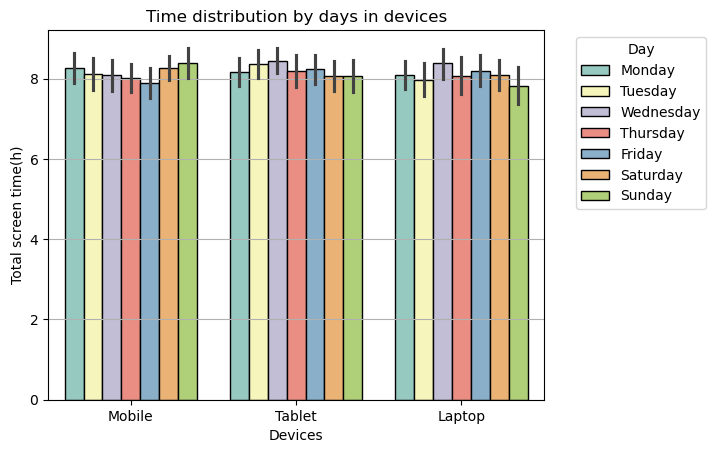

In [43]:
sns.barplot(data,x='primary_device',y='total_screen_time',hue='day',estimator='mean',palette='Set3',edgecolor='black')
plt.grid(axis='y')
plt.title('Time distribution by days in devices')
plt.legend(title='Day',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Devices')
plt.ylabel('Total screen time(h)')
plt.show()

<div class="alert alert-info"> 
   &#9673; Mobile use is active on Saturdays and Sundays and less active on Friday<br>
   &#9673; Tablet usage is high on Wednesdays and Tuesdays and is less on Sundays and Saturdays<br>
   &#9673; Laptop have a high usage on Wednesday and least usage on Sundays.<br>
    &#9673; Laptops are more concentrated during weekdays, aligning with work or study routines, then fall off on weekends.<br>
    &#9673; Tablets show consistent usage.<br>
    &#9673; Mobile and tablet show a peak time on weekends.
</div>

**BARPLOT-** To show screen time in different devices distinguished by internet type

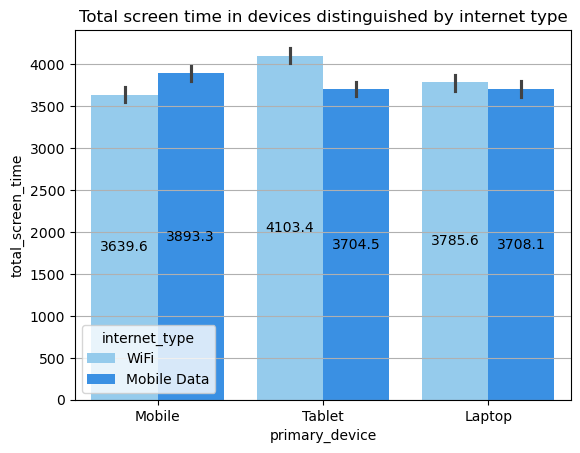

In [44]:
net=sns.barplot(df,x='primary_device',y='total_screen_time',hue='internet_type',palette=['lightskyblue','dodgerblue'],estimator='sum')
for c in net.containers:
    net.bar_label(c,label_type='center')
plt.grid(axis='y')
plt.title('Total screen time in devices distinguished by internet type')
plt.show()

<div class="alert alert-info"> 
   &#9673; Mobiles users commonly prefer mobile data for internet.<br>
    &#9673; Mobile users rely heavily on data plans, possibly due to portability and constant connectivity.
    &#9673; Tablet user prefer wifi over mobile data.<br>
   &#9673; Laptop users, when compared with mobile data, highly prefers wifi but usage of mobile data is not much less. It is evenly distributed.<br>
     &#9673; Among all 3 devices screen time is high on tablet with the usage of wifi.<br>
     &#9673; Among all 3 devices screen time is low on mobile with the usage of wifi.<br>
    &#9673; A high screen time spent by using mobile data is observed in mobile phones and low in tablet.
</div>

**BARPLOT-** monthly screen time with different internet type

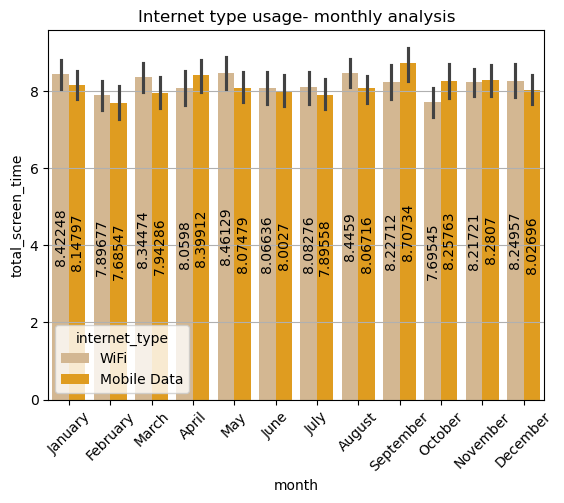

In [45]:
monthly=sns.barplot(data,x='month',y='total_screen_time',hue='internet_type',palette=['burlywood','orange'])
for c in monthly.containers:
    monthly.bar_label(c,label_type='center',rotation=90)
plt.title('Internet type usage- monthly analysis')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

<div class="alert alert-info"> 
   &#9673;  Mobile data usage is high on September and low on February.<br>
   &#9673;  Wifi usage is high on May and low on October.<br>
   &#9673; In most months, WiFi usage appears higher than Mobile Data, suggesting that people prefer stable, home/office connections for screen activities.<br>
    &#9673; No month shows a dramatic drop or spike.<br>
    &#9673; The consistently high values highlight a strong dependence on internet connectivity for daily activities, regardless of season.<br>
</div>

**HEATMAP-** Shows a correlation among variables, age,entertainment hours, social meadia hours, and work or study hours

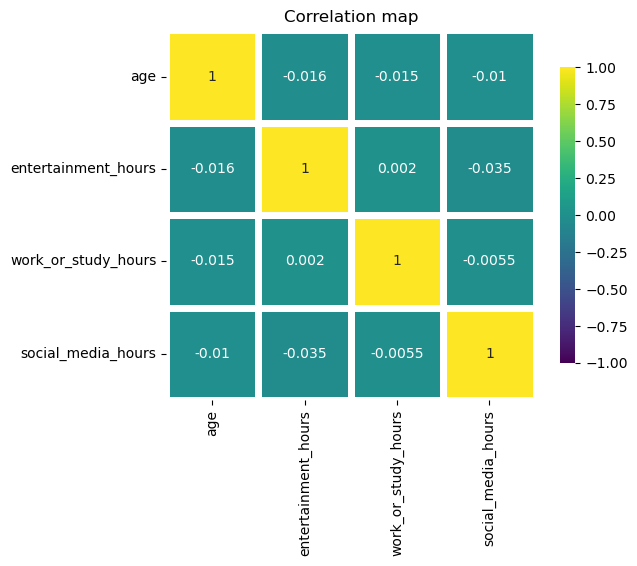

In [46]:
corr=data[['age','entertainment_hours','work_or_study_hours','social_media_hours']].corr()
sns.heatmap(corr,cmap='viridis',annot=True,center=0,vmin=-1,vmax=1,square=True,linewidths=5,cbar_kws={"shrink": .8})
plt.title('Correlation map')
plt.show()

<div class="alert alert-info">
 &#9673; Age has very weak negative correlations with all three activities, - This means as age increases, there’s a slight tendency for screen time in these categories to decrease, but the relationship is insignificant.<br>
&#9673; Entertainment has a very weak negative correlation with social media, suggesting those who spend more time on entertainment may spend slightly less on social media, but the effect is minimal<br>
 &#9673; Entertainment hours have no correlation with work/study hours.<br>
  &#9673; Social media and work/study hours are independent to each other.<br>
&#9673; In short, screen time habits appear highly individual.

</div>

***
<p style="font-family: Courier; font-size:30px;"> <b>REPORT </b> </p> 

***

<div style="font-family: 'Times New Roman'; font-size:20px;background-color:turquoise; padding:5px;"> <b>FINDINGS </div> 

&#10147; About 53% of people devote more time on leisure screen time.<br>
&#10147; Students have high leisure screen time, more than 4 hours.<br>
&#10147; Almost 10% of people spend half of the day in screen.<br>
&#10147; Almost 80% of people having high leisure screen time.<br>
&#10147; Age cant predict screen time on one individual, but an overall findings suggest screen time decrease with increase in age.<br>
&#10147; Only 0.01% of people spend screen time less than 4 hours.<br>
&#10147; Total screen time averages between 7 to 8 hours.<br>
&#10147; Most of the daily screen time is spend for work/study, an average 4 hours daily.<br>
&#10147; Students are mostly engaged in mobile phones while workers are engaged in laptops.<br>
&#10147; All three devices having high demand.<br>
&#10147; Mobile data usage is high in mobile phones.<br>
&#10147; Wifi usage is high in tablets.

<div style="font-family: 'Times New Roman'; font-size:20px;background-color:turquoise; padding:5px;"> <b>CONCLUSION </div>

&#10147; The relatively even distribution across most days highlights that internet usage is now a daily habit, not limited to specific times.<br>
&#10147; Sustained high screen time raises concerns about digital well being.<br>
&#10147; Entertainment and social media hours remain more stable, suggesting they are habitual daily activities rather than seasonal.<br>
&#10147; People choice in how they allocate screen time don't strongly predict one another.<br>
&#10147; Unhealthy screen time is wide spread issue across all groups.<br>
&#10147; The high demand in all devices suggest that, desisions should focus in all three devices rather than just one.
&#10147; Laptop users prefer to balance work mobility and home use.<br>
&#10147; While tablet users prefer comfort and stability.<br>
&#10147; Mobile users focus on accessibility and mobility.

<div style="font-family: 'Times New Roman'; font-size:20px;background-color:turquoise; padding:5px;"> <b>RECOMMENDATIONS </div>

<b><u> For Governmental purpose </b></u> <br>
&#10147; Awareness campaigns around social media and entertainment use.<br>
&#10147; Promoting screen breaks and offline activities among employees.<br>
&#10147; Encouraging physical, social, and outdoor activities to balance leisure time.<br>
<b><u> For Business and Marketing </b></u> <br>
&#10147; Telecome providers can bring new plans separately for students and employees.<br>
&#10147; Since wifi users are high, encourage more subsciption plans.<br>
&#10147; Promoting more weekend recharge plans could bring profit.<br>
&#10147; Ensure devices access irespective of age.<br>
<b><u> For Education sector </b></u> <br>
&#10147; Encourage outdoor activities in students maintaining their study progress.<br>
&#10147; Conduct programs to ensure students mental and physical health.<br>
&#10147; Conduct awareness programs for parents about screen time usage in children.<br>
<b><u> For Healthcare </b></u> <br>
&#10147; Conduct awareness programs on how screen time affect mental and physical health.<br>
&#10147; Study health risks due to high screen time.<br>
&#10147; Bring health tips for workers who spend most of the time in devices.<br>
<b><u> For Technology development </b></u> <br>
&#10147; Develop apps to maintain screen time in device users.<br>
&#10147; Develop user friendly interface suitable for all ages.<br>
<b><u> For Social research</b></u> <br>
&#10147; Study how screen time affect daily life.<br>
&#10147; Study how internet usage affect daily activities.<br>
&#10147; Study pros and cons of Internet.